# Torch-ification of our previous work so far!
Our api will be similar to that of `nn.module`

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open("names.txt", "r").read().splitlines()

In [3]:
chars = sorted(list(set("".join(words))))
str_to_int = {str: (int + 1) for int, str in enumerate(chars)}
str_to_int["."] = 0
int_to_str = {int: str for str, int in str_to_int.items()}

print(int_to_str)
print(str_to_int)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [5]:
def build_dataset(words: list):
    block_size = 3
    X, Y = [], []

    for w in words:
        window = [0] * block_size # create a sliding window of size defined by block_size that starts as ...
        for c in w + '.':
            ix = str_to_int[c]
            X.append(window)
            Y.append(ix)
            #print("".join(int_to_str[i] for i in window), " --->", c)
            window = window[1:] + [ix] # crop out the first character and add the next character
    
    X, Y = torch.tensor(X), torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
    
import random
random.seed(42)

random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

print(len(words), n1, n2)

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1: n2])
Xtest, Ytest = build_dataset(words[n2:])

g = torch.Generator().manual_seed(2147483647)

32033 25626 28829
torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [49]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in ** 0.5)
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # buffers
        self.running_mean = torch.zeros(dim) # creates tensor of shape (dim, ) and not (1, dim) like in non-torch version
        self.running_var = torch.ones(dim) #  because broadcasting will handle it by prepending a dimension from left
        # trainable parameters
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        
    def __call__(self, x):
        if self.training:
            x_mean = x.mean(0, keepdim=True)
            x_var = x.var(0, keepdim=True)
            # can update the buffers here as well ig? 
        else:
            x_mean = self.running_mean
            x_var = self.running_var
        xhat = (x - x_mean) / torch.sqrt(x_var + self.eps) # normalize to unit std/var
        self.out = self.gamma * xhat + self.beta # scale and offset
        # buffer update goes here
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + (self.momentum * x_mean)
                self.running_var = (1 - self.momentum) * self.running_var + (self.momentum * x_var)
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [ ]:
# Initialize network
block_size = 3
n_emb = 10
n_hidden = 100
vocab_size = 27
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_emb), generator=g)
# can set bias to True if we are not using Batch Norm
# PS: can remove Kaiming initialization w/ batch norm and still get good results
layers = [
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
#layers = [
#    Linear(n_emb * block_size, n_hidden, bias=True), Tanh(),
#    Linear(n_hidden, n_hidden, bias=True), Tanh(),
#    Linear(n_hidden, n_hidden, bias=True), Tanh(),
#    Linear(n_hidden, n_hidden, bias=True), Tanh(),
#    Linear(n_hidden, n_hidden, bias=True), Tanh(),
#    Linear(n_hidden, vocab_size, bias=True),
#]

with torch.no_grad():
    # make output layer less confident to get uniform probability distribution at training's start!
    #layers[-1].weight *= 0.1 # only use without batch norm!
    layers[-1].gamma *= 0.1
    # apply gain to other layers (not output because we are not applying Tanh() here, so no need to fight contractive action)
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47024


In [103]:
# Training loop
max_steps = 200000
batch_size = 32
loss_i = []
update_ratios = []

for i in range(max_steps):
    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # fwd pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers: # input passes thru layers
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f"{i}/{max_steps}: {loss.item():.4f}")
    loss_i.append(loss.log10().item())
    
    # also store update to curr_weight ratio
    with torch.no_grad():
        update_ratios.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
        
    #break
    #if i >= 1000:
    #    break

0/200000: 2.3808
10000/200000: 2.0592
20000/200000: 2.2390
30000/200000: 2.2169
40000/200000: 2.0328
50000/200000: 2.3372
60000/200000: 2.0176
70000/200000: 2.3571
80000/200000: 2.0372
90000/200000: 2.1405
100000/200000: 1.6272
110000/200000: 1.9988
120000/200000: 2.5745
130000/200000: 1.7980
140000/200000: 2.2296
150000/200000: 1.8499
160000/200000: 1.9077
170000/200000: 2.1687
180000/200000: 1.9082
190000/200000: 1.8488


## Training Diagnostics
We can use these methods to check how effective our current training methods/hyperparameters are! The last one in particular is quite interesting.

layer 2 (      Tanh): mean +0.01, std 0.83, saturated: 36.25%
layer 5 (      Tanh): mean -0.01, std 0.89, saturated: 55.69%
layer 8 (      Tanh): mean -0.02, std 0.90, saturated: 55.31%
layer 11 (      Tanh): mean -0.00, std 0.90, saturated: 56.94%
layer 14 (      Tanh): mean -0.03, std 0.91, saturated: 58.34%


Text(0.5, 1.0, 'activation distribution')

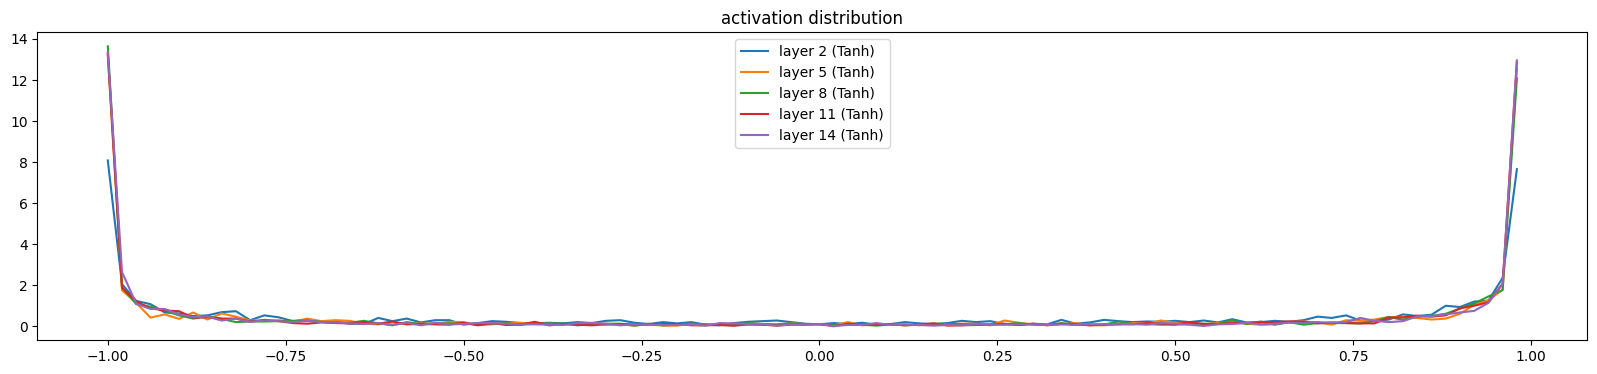

In [104]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000006, std 3.831127e-03
layer 5 (      Tanh): mean +0.000006, std 3.783183e-03
layer 8 (      Tanh): mean +0.000094, std 3.667173e-03
layer 11 (      Tanh): mean -0.000005, std 3.610538e-03
layer 14 (      Tanh): mean +0.000083, std 4.106718e-03


Text(0.5, 1.0, 'gradient distribution')

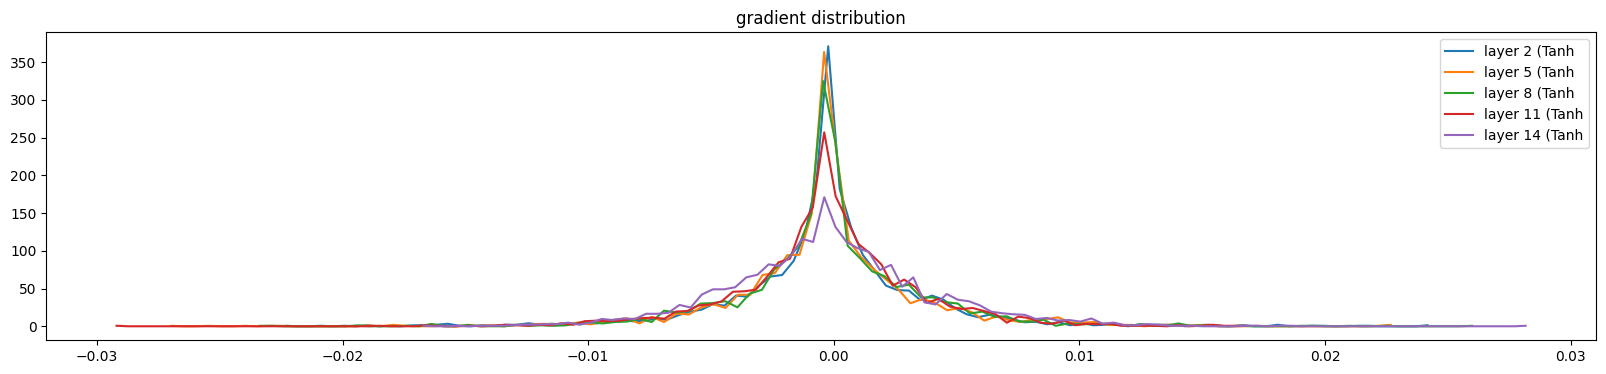

In [105]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000854 | std 1.595917e-02 | grad:data ratio 1.304610e-02
weight  (30, 100) | mean +0.000025 | std 9.428350e-03 | grad:data ratio 1.896893e-02
weight (100, 100) | mean +0.000090 | std 6.004963e-03 | grad:data ratio 2.001991e-02
weight (100, 100) | mean -0.000037 | std 6.520184e-03 | grad:data ratio 2.223132e-02
weight (100, 100) | mean -0.000076 | std 6.260032e-03 | grad:data ratio 2.197322e-02
weight (100, 100) | mean +0.000034 | std 5.882965e-03 | grad:data ratio 2.112772e-02
weight  (100, 27) | mean -0.000030 | std 1.178920e-02 | grad:data ratio 3.215008e-02


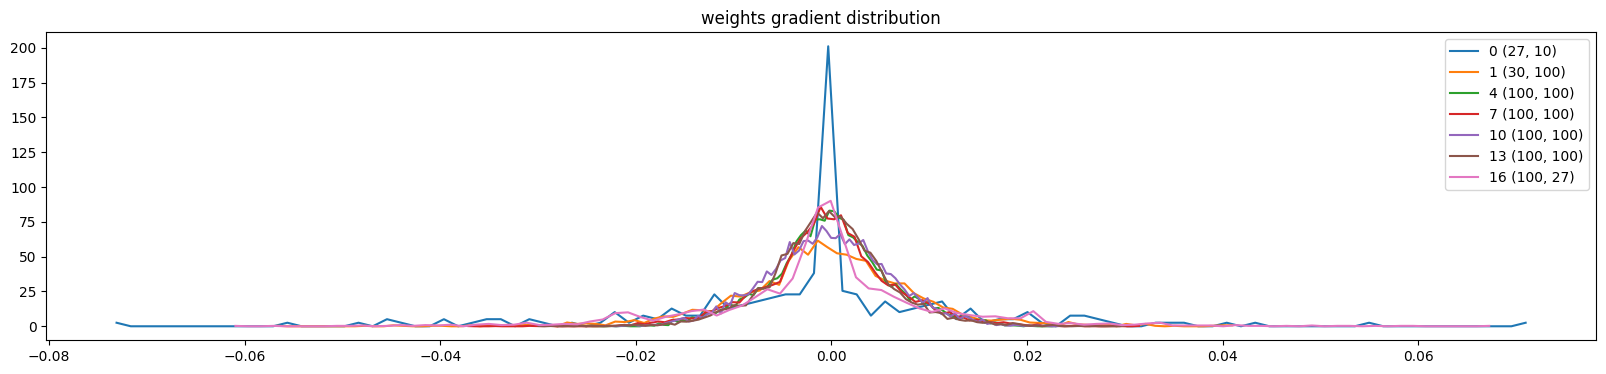

In [106]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

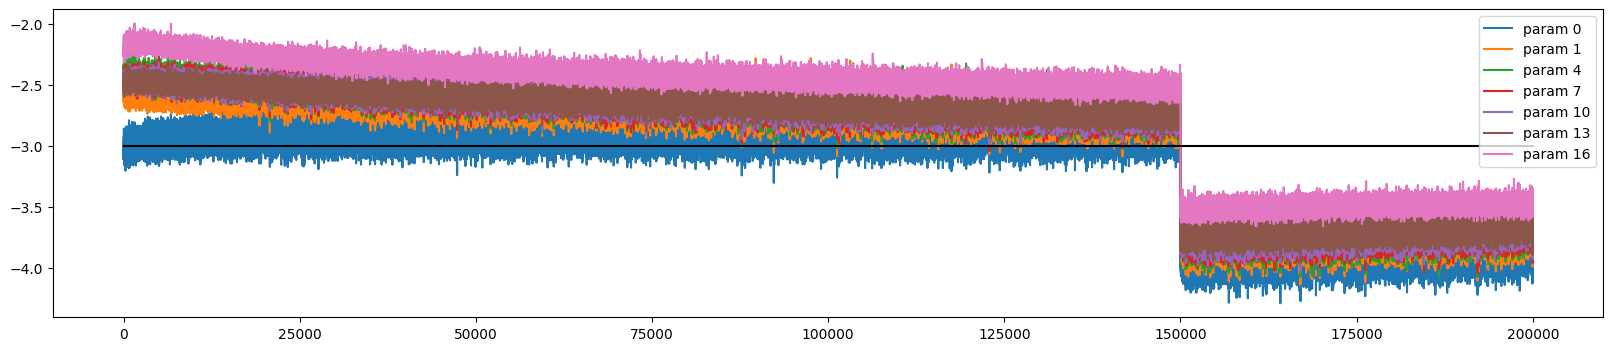

In [107]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([update_ratios[j][i] for j in range(len(update_ratios))])
        legends.append('param %d' % i)
plt.plot([0, len(update_ratios)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot. can be slightly larger but lower means less effective learning
plt.legend(legends);
# bigger values imply that layers are learning very fast, so a good indicator of layerwise progress in training!
# increasing the learning rate can fix the update ratios of slow learning params below 1e-3.

## Final checks and sampling!

In [108]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xtest, Ytest),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

# put layers into eval mode
for layer in layers:
    layer.training = False
split_loss('train')
split_loss('val')



train 1.9582722187042236
val 2.0856411457061768


In [112]:
for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        # fwd pass
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break
    print(''.join(int_to_str[i] for i in out))

jus.
rone.
kynzi.
quen.
dilla.
niccaydinseleson.
alys.
tan.
nevy.
arto.
